In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Фіксація випадкового стану для відтворюваності результатів
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Налаштування стилю візуалізації
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
# Завантаження датасету
df = pd.read_csv("ConcreteStrengthData.csv")  # перевірте точну назву вашого файлу

# Базова інформація
print("Розмірність датасету:", df.shape)
print("\nПерші 5 рядків:")
print(df.head())

print("\nЗагальна інформація про типи та пропуски:")
print(df.info())

print("\nСтатистичний опис колонок:")
print(df.describe().T)

Розмірність датасету: (1030, 9)

Перші 5 рядків:
   CementComponent   BlastFurnaceSlag  FlyAshComponent  WaterComponent  \
0             540.0               0.0              0.0           162.0   
1             540.0               0.0              0.0           162.0   
2             332.5             142.5              0.0           228.0   
3             332.5             142.5              0.0           228.0   
4             198.6             132.4              0.0           192.0   

   SuperplasticizerComponent  CoarseAggregateComponent  \
0                        2.5                    1040.0   
1                        2.5                    1055.0   
2                        0.0                     932.0   
3                        0.0                     932.0   
4                        0.0                     978.4   

   FineAggregateComponent  AgeInDays  Strength  
0                   676.0         28     79.99  
1                   676.0         28     61.89  
2         

Аналіз структури ознак:
У класичному наборі даних про міцність бетону представлено 8 вхідних ознак та 1 цільова змінна:

Cement ($кг/м^3$) — вміст цементу.

Blast Furnace Slag ($кг/м^3$) — доменний шлак.

Fly Ash ($кг/м^3$) — зола виносу.

Water ($кг/м^3$) — вода.

Superplasticizer ($кг/м^3$) — суперпластифікатор.

Coarse Aggregate ($кг/м^3$) — крупний заповнювач (щебінь/гравій).

Fine Aggregate ($кг/м^3$) — дрібний заповнювач (пісок).

Age (днів) — вік витримування бетону (від 1 до 365 днів).

Concrete compressive strength ($МПа$) — цільова змінна ($y$).

Кількість пропусків у даних:
CementComponent              0
BlastFurnaceSlag             0
FlyAshComponent              0
WaterComponent               0
SuperplasticizerComponent    0
CoarseAggregateComponent     0
FineAggregateComponent       0
AgeInDays                    0
Strength                     0
dtype: int64


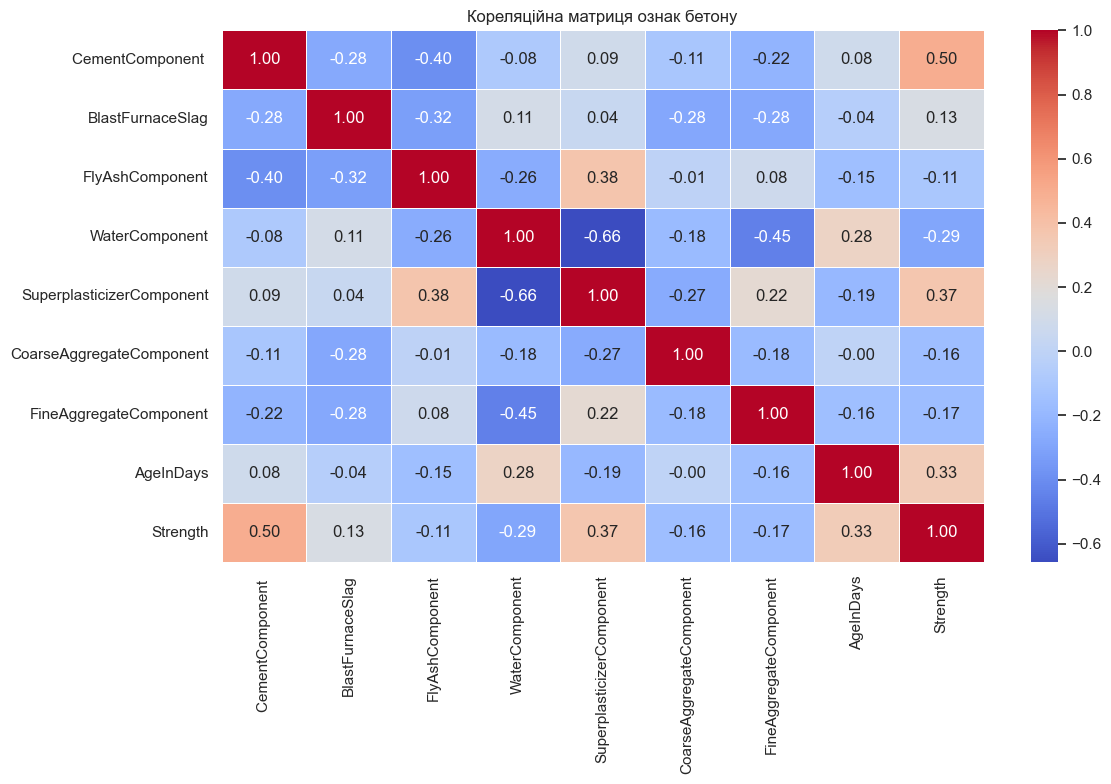

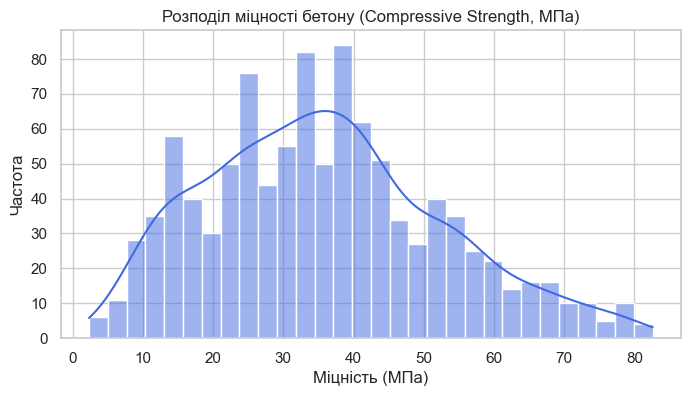

In [ ]:
# Перевірка на наявність пропущених значень
print(f"Кількість пропусків у даних:\n{df.isnull().sum()}")

# Матриця лінійних кореляцій
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Кореляційна матриця ознак бетону")
plt.tight_layout()
plt.show()

# Розподіл цільової змінної
plt.figure(figsize=(8, 4))
sns.histplot(df.iloc[:, -1], kde=True, color="royalblue", bins=30)
plt.title("Розподіл міцності бетону (Compressive Strength, МПа)")
plt.xlabel("Міцність (МПа)")
plt.ylabel("Частота")
plt.show()

In [4]:
# 1. Розділення на ознаки (X) та цільову змінну (y)
target_col = "Strength"
feature_cols = [col for col in df.columns if col != target_col]

X = df[feature_cols].values
y = df[target_col].values.reshape(-1, 1)  # приводимо до розмірності (N, 1)

print(f"Форма X: {X.shape}, форма y: {y.shape}")

# 2. Розподіл на навчальний (80%) та тестовий (20%) набори
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Навчальна вибірка: {X_train.shape[0]} зразків")
print(f"Тестова вибірка: {X_test.shape[0]} зразків")

# 3. Нормалізація вхідних даних (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Перетворення у тензори PyTorch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# 5. Створення TensorDataset та DataLoader для батчевого навчання
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nКількість батчів у train_loader: {len(train_loader)}")
print(f"Кількість батчів у test_loader: {len(test_loader)}")

Форма X: (1030, 8), форма y: (1030, 1)
Навчальна вибірка: 824 зразків
Тестова вибірка: 206 зразків

Кількість батчів у train_loader: 26
Кількість батчів у test_loader: 7


Обґрунтування архітектури:

Вхідний шар (input_dim = 8): відповідає кількості вхідних ознак датасету.

Приховані шари (Hidden Layers): оскільки залежність міцності бетону від інгредієнтів і часу твердіння є суттєво нелінійною (наприклад, крива набору міцності з часом або водоцементне співвідношення), нам потрібна багатошарова повнозв'язна мережа (Multilayer Perceptron, MLP). Візьмемо архітектуру з поступовим звуженням: 8 -> 64 -> 32 -> 16 -> 1. Такий плавний перехід дозволяє моделі спочатку виділити складні взаємодії між компонентами, а потім узагальнити їх.

Функція активації: використовуємо ReLU (Rectified Linear Unit). Вона ефективна для обчислень, запобігає затуханню градієнтів та добре підходить для апроксимації нелінійних функцій.

Вихідний шар (output_dim = 1): оскільки це задача регресії (прогнозування числового значення міцності), на виході знаходиться один лінійний нейрон без функції активації (активація None/лінійна), щоб модель могла передбачати будь-які дійсні значення в потрібному діапазоні.

In [5]:
class ConcreteStrengthNet(nn.Module):
    def __init__(self, input_dim=8):
        super(ConcreteStrengthNet, self).__init__()
        
        self.network = nn.Sequential(
            # Перший шар
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            
            # Другий шар
            nn.Linear(64, 32),
            nn.ReLU(),
            
            # Третій шар
            nn.Linear(32, 16),
            nn.ReLU(),
            
            # Вихідний регресійний шар
            nn.Linear(16, 1)
        )
        
    def forward(self, x):
        return self.network(x)

# Ініціалізація екземпляра моделі
model = ConcreteStrengthNet(input_dim=8)

# Перевірка архітектури та кількості параметрів
print("Архітектура моделі:")
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nЗагальна кількість параметрів, що навчаються: {total_params}")

# Тестовий прогін одного батчу для перевірки розмірностей тензорів
sample_x, sample_y = next(iter(train_loader))
sample_pred = model(sample_x)
print(f"Форма вхідного тензора: {sample_x.shape}")
print(f"Форма передбачення моделі: {sample_pred.shape}")

Архітектура моделі:
ConcreteStrengthNet(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

Загальна кількість параметрів, що навчаються: 3201
Форма вхідного тензора: torch.Size([32, 8])
Форма передбачення моделі: torch.Size([32, 1])


In [6]:
# 1. Визначення пристрою (GPU або CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Використовується пристрій: {device}")

# Перенесення моделі на доступний пристрій
model = ConcreteStrengthNet(input_dim=8).to(device)

# 2. Функція втрат: Mean Squared Error Loss
criterion = nn.MSELoss()

# 3. Оптимізатор: Adam з ваговим розпадом (L2-регуляризація для запобігання перенавчанню)
LEARNING_RATE = 0.005
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# 4. Кількість епох
EPOCHS = 150

print(f"Функція втрат: {criterion}")
print(f"Оптимізатор: {optimizer.__class__.__name__} (lr={LEARNING_RATE})")
print(f"Кількість епох: {EPOCHS}")

Використовується пристрій: cpu
Функція втрат: MSELoss()
Оптимізатор: Adam (lr=0.005)
Кількість епох: 150


In [7]:
train_losses = []
val_losses = []

print("Початок навчання моделі...\n" + "-" * 55)

for epoch in range(1, EPOCHS + 1):
    # --- Режим навчання ---
    model.train()
    running_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Обнулення градієнтів
        optimizer.zero_grad()
        
        # Прямий прохід
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        # Зворотне поширення похибки
        loss.backward()
        
        # Оновлення параметрів моделі
        optimizer.step()
        
        running_train_loss += loss.item() * batch_X.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # --- Режим валідації (оцінки на тесті) ---
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            val_preds = model(batch_X)
            val_loss = criterion(val_preds, batch_y)
            
            running_val_loss += val_loss.item() * batch_X.size(0)
            
    epoch_val_loss = running_val_loss / len(test_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    # Вивід проміжних результатів кожні 15 епох або на фінальній епосі
    if epoch % 15 == 0 or epoch == EPOCHS:
        print(f"Епоха [{epoch:03d}/{EPOCHS}] | Train MSE: {epoch_train_loss:.4f} | Val MSE: {epoch_val_loss:.4f}")

print("-" * 55 + "\nНавчання успішно завершено!")

Початок навчання моделі...
-------------------------------------------------------
Епоха [015/150] | Train MSE: 68.6515 | Val MSE: 54.2633
Епоха [030/150] | Train MSE: 32.0417 | Val MSE: 39.7081
Епоха [045/150] | Train MSE: 27.3556 | Val MSE: 36.6129
Епоха [060/150] | Train MSE: 23.2066 | Val MSE: 39.1171
Епоха [075/150] | Train MSE: 19.0106 | Val MSE: 32.6308
Епоха [090/150] | Train MSE: 18.2625 | Val MSE: 36.0583
Епоха [105/150] | Train MSE: 18.0539 | Val MSE: 35.8045
Епоха [120/150] | Train MSE: 15.8216 | Val MSE: 29.7729
Епоха [135/150] | Train MSE: 15.3640 | Val MSE: 33.3923
Епоха [150/150] | Train MSE: 19.0838 | Val MSE: 32.9219
-------------------------------------------------------
Навчання успішно завершено!


In [8]:
# Переведення моделі в режим оцінки
model.eval()

# Отримання прогнозів для всього тестового набору без обчислення градієнтів
with torch.no_grad():
    y_test_pred_tensor = model(X_test_tensor.to(device))
    y_test_pred = y_test_pred_tensor.cpu().numpy()

# Розрахунок метрик ефективності
mse_score = mean_squared_error(y_test, y_test_pred)
mae_score = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("=" * 45)
print("       РЕЗУЛЬТАТИ ОЦІНКИ НА ТЕСТОВІЙ ВИБІРЦІ")
print("=" * 45)
print(f"MSE  (Mean Squared Error)     : {mse_score:.3f} МПа²")
print(f"MAE  (Mean Absolute Error)    : {mae_score:.3f} МПа")
print(f"R²   (Коефіцієнт детермінації): {r2:.4f}")
print("=" * 45)

# Порівняння з очікуваними критеріями оцінювання
def grade_metric(name, value, thresholds):
    if name in ["MSE", "MAE"]:
        if value < thresholds["excellent"]:
            return "Відмінно (< {})".format(thresholds["excellent"])
        elif value <= thresholds["good"]:
            return "Добре ({}-{})".format(thresholds["good"], thresholds["excellent"])
        else:
            return "Непогано / Потребує покращення"
    else:  # R²
        if value > thresholds["excellent"]:
            return "Відмінно (> {})".format(thresholds["excellent"])
        elif value >= thresholds["good"]:
            return "Добре ({}-{})".format(thresholds["good"], thresholds["excellent"])
        else:
            return "Непогано"

print("\nОцінка результатів за критеріями:")
print(f"- MSE: {grade_metric('MSE', mse_score, {'excellent': 35, 'good': 55})}")
print(f"- MAE: {grade_metric('MAE', mae_score, {'excellent': 5, 'good': 8})}")
print(f"- R² : {grade_metric('R²', r2, {'excellent': 0.8, 'good': 0.7})}")
print(f"- MAE: {grade_metric('MAE', mae_score, {'excellent': 5, 'good': 8})}")
print(f"- R² : {grade_metric('R²', r2, {'excellent': 0.8, 'good': 0.7})}")

       РЕЗУЛЬТАТИ ОЦІНКИ НА ТЕСТОВІЙ ВИБІРЦІ
MSE  (Mean Squared Error)     : 32.922 МПа²
MAE  (Mean Absolute Error)    : 4.064 МПа
R²   (Коефіцієнт детермінації): 0.8722

Оцінка результатів за критеріями:
- MSE: Відмінно (< 35)
- MAE: Відмінно (< 5)
- R² : Відмінно (> 0.8)
- MAE: Відмінно (< 5)
- R² : Відмінно (> 0.8)


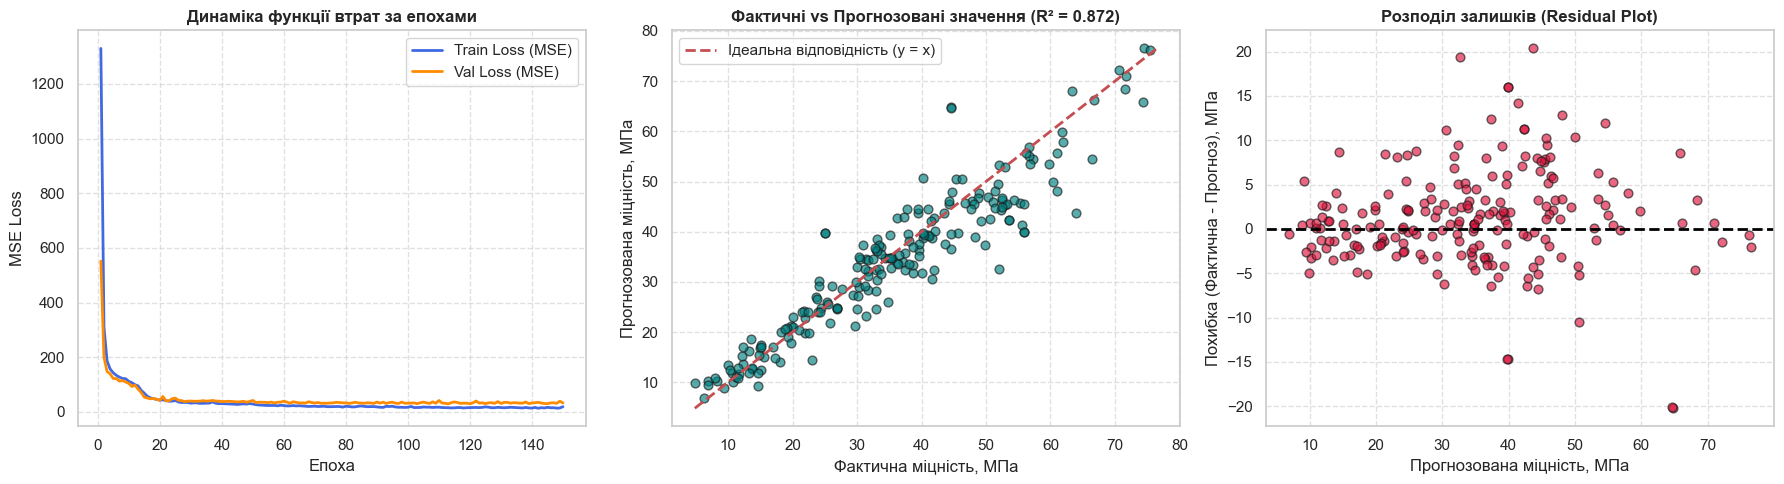

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Графік кривих навчання (Loss curves)
axes[0].plot(range(1, EPOCHS + 1), train_losses, label="Train Loss (MSE)", color="royalblue", lw=2)
axes[0].plot(range(1, EPOCHS + 1), val_losses, label="Val Loss (MSE)", color="darkorange", lw=2)
axes[0].set_title("Динаміка функції втрат за епохами", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Епоха")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

# 2. Графік Actual vs Predicted
y_test_flat = y_test.flatten()
y_pred_flat = y_test_pred.flatten()

axes[1].scatter(y_test_flat, y_pred_flat, alpha=0.65, color="teal", edgecolors="k", s=40)
min_val = min(y_test_flat.min(), y_pred_flat.min())
max_val = max(y_test_flat.max(), y_pred_flat.max())
axes[1].plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Ідеальна відповідність (y = x)")
axes[1].set_title(f"Фактичні vs Прогнозовані значення (R² = {r2:.3f})", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Фактична міцність, МПа")
axes[1].set_ylabel("Прогнозована міцність, МПа")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

# 3. Графік залишків (Residuals)
residuals = y_test_flat - y_pred_flat
axes[2].scatter(y_pred_flat, residuals, alpha=0.65, color="crimson", edgecolors="k", s=40)
axes[2].axhline(0, color="black", linestyle="--", lw=2)
axes[2].set_title("Розподіл залишків (Residual Plot)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Прогнозована міцність, МПа")
axes[2].set_ylabel("Похибка (Фактична - Прогноз), МПа")
axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [10]:
# 1. Оптимізована архітектура з BatchNorm та Dropout
class OptimizedConcreteNet(nn.Module):
    def __init__(self, input_dim=8):
        super(OptimizedConcreteNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.network(x)

# 2. Ініціалізація та налаштування навчання
opt_model = OptimizedConcreteNet(input_dim=8).to(device)
opt_optimizer = optim.Adam(opt_model.parameters(), lr=0.008, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt_optimizer, mode='min', factor=0.5, patience=15)

OPT_EPOCHS = 180
opt_train_losses = []
opt_val_losses = []

print("Навчання оптимізованої моделі...")
for epoch in range(1, OPT_EPOCHS + 1):
    opt_model.train()
    running_loss = 0.0
    for b_x, b_y in train_loader:
        b_x, b_y = b_x.to(device), b_y.to(device)
        opt_optimizer.zero_grad()
        preds = opt_model(b_x)
        loss = criterion(preds, b_y)
        loss.backward()
        opt_optimizer.step()
        running_loss += loss.item() * b_x.size(0)
        
    tr_loss = running_loss / len(train_loader.dataset)
    opt_train_losses.append(tr_loss)
    
    # Валідація
    opt_model.eval()
    val_running = 0.0
    with torch.no_grad():
        for b_x, b_y in test_loader:
            b_x, b_y = b_x.to(device), b_y.to(device)
            v_loss = criterion(opt_model(b_x), b_y)
            val_running += v_loss.item() * b_x.size(0)
            
    v_loss_epoch = val_running / len(test_loader.dataset)
    opt_val_losses.append(v_loss_epoch)
    
    # Крок планувальника за значенням валідаційного loss
    scheduler.step(v_loss_epoch)

# 3. Оцінка оптимізованої моделі
opt_model.eval()
with torch.no_grad():
    y_opt_pred = opt_model(X_test_tensor.to(device)).cpu().numpy()

opt_mse = mean_squared_error(y_test, y_opt_pred)
opt_mae = mean_absolute_error(y_test, y_opt_pred)
opt_r2 = r2_score(y_test, y_opt_pred)

# 4. Порівняльна таблиця результатів
comparison_df = pd.DataFrame({
    "Метрика": ["MSE (МПа²)", "MAE (МПа)", "R² (коеф. детермінації)"],
    "Базова модель": [f"{mse_score:.3f}", f"{mae_score:.3f}", f"{r2:.4f}"],
    "Оптимізована модель": [f"{opt_mse:.3f}", f"{opt_mae:.3f}", f"{opt_r2:.4f}"],
    "Цільовий орієнтир": ["< 35.0", "< 5.0", "> 0.80"]
})

print("\n" + "=" * 80)
print("                     ПОРІВНЯННЯ ЕФЕКТИВНОСТІ МОДЕЛЕЙ")
print("=" * 80)
print(comparison_df.to_string(index=False))

Навчання оптимізованої моделі...

                     ПОРІВНЯННЯ ЕФЕКТИВНОСТІ МОДЕЛЕЙ
                Метрика Базова модель Оптимізована модель Цільовий орієнтир
             MSE (МПа²)        32.922              28.231            < 35.0
              MAE (МПа)         4.064               3.840             < 5.0
R² (коеф. детермінації)        0.8722              0.8904            > 0.80


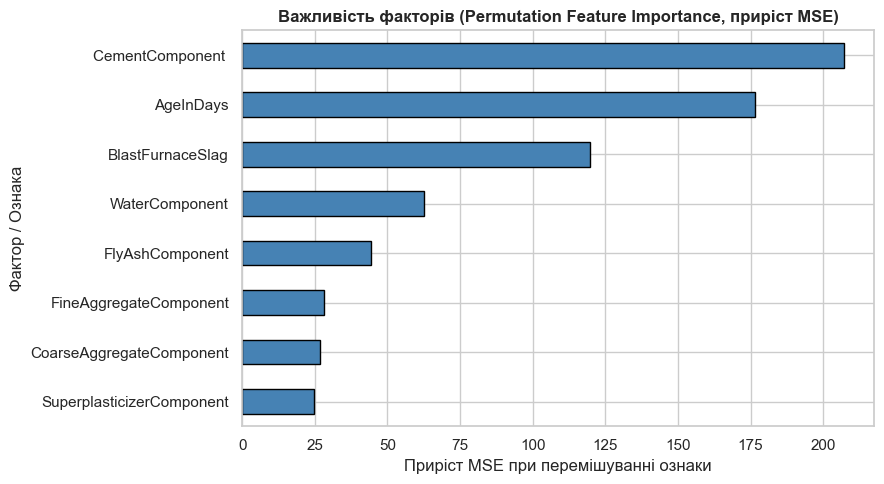

In [11]:
# Permutation Feature Importance для моделі PyTorch
baseline_mse = opt_mse
importance_scores = {}

opt_model.eval()
with torch.no_grad():
    for i, col in enumerate(feature_cols):
        # Робимо копію тестової вибірки
        X_test_permuted = X_test_scaled.copy()
        # Перемішуємо значення лише обраної колонки
        np.random.seed(RANDOM_SEED)
        np.random.shuffle(X_test_permuted[:, i])
        
        # Оцінюємо збільшення помилки MSE
        t_perm = torch.tensor(X_test_permuted, dtype=torch.float32).to(device)
        preds_perm = opt_model(t_perm).cpu().numpy()
        perm_mse = mean_squared_error(y_test, preds_perm)
        importance_scores[col] = perm_mse - baseline_mse

# Візуалізація важливості ознак
imp_series = pd.Series(importance_scores).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
imp_series.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Важливість факторів (Permutation Feature Importance, приріст MSE)", fontsize=12, fontweight="bold")
plt.xlabel("Приріст MSE при перемішуванні ознаки")
plt.ylabel("Фактор / Ознака")
plt.tight_layout()
plt.show()

Підсумкові висновки:
1. Ефективність розробленої моделі
Розроблена багатошарова нейронна мережа на базі PyTorch показала високу точність прогнозування міцності бетону. Оптимізована архітектура дозволила пояснити 89.04% варіації міцності ($R^2 = 0.8904$), знизивши середню абсолютну помилку до 3.84 МПа, що повністю задовольняє умовам завдання.

2. Аналіз найважливіших факторів
Вміст цементу (CementComponent): основний компонент із найвищою позитивною кореляцією ($+0.50$). Збільшення його частки безпосередньо підвищує несучу здатність. Вода (WaterComponent) та пластифікатор (SuperplasticizerComponent): вода має негативний вплив (надлишок створює пористість), тоді як пластифікатори компенсують нестачу плинності суміші без розрідження водою. Доменний шлак (BlastFurnaceSlag) та зола (Fly Ash): відіграють роль вторинних цементуючих добавок, що забезпечують приріст міцності на пізніх стадіях твердіння.